<a href="https://colab.research.google.com/github/allenswdb/TReND-CaMinA/blob/main/notebooks/Kenya26/03_04-Wed1toThu2-AllenTutorial/project_templates/Project_6_Decoding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="background: #F0FAFF; border-radius: 3px; padding: 10px;">
    <h1> Project 6:  Decoding with the Allen Brain Observatory </h1>

In this project, we are going to explore decoding of stimulus informatin using data from the Allen Brain Observatory.  We will look at how we can decode stimulus information and ask questions about what doing so can tell us about neural responses.  This project picks up where the decoding tutorial left off.
    
For the examples we provide we will look at the 'Drifting Gratings' stimulus.  You might consider a similar project that looks at another stimulus.


</div>

In [ ]:
# @title Run to initialize Allen Brain Observatory on Colab {display-mode: "form" }

# run only once per runtime/session, and only if running in colab
# the runtime will need to restxart after
%%capture
!apt install s3fs

!pip uninstall -y numpy pandas
!pip install git+https://github.com/AllenInstitute/AllenSDK@1bdca3ad884c3a5edea8236161424650603e6f29 "numpy == 1.26.4" "pandas == 2.3.0" "matplotlib > 3.8.0" "statsmodels >= 0.14.4"
import allensdk
print('allensdk imported successfully')

!mkdir -p /data/allen-brain-observatory/
!s3fs allen-brain-observatory /data/allen-brain-observatory/ -o public_bucket=1

import time
print("Runtime is now restarting...")
print("You can ignore the error message [Your session crashed for an unknown reason.]")
time.sleep(5)
exit()

### Standard imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# we're going to need lists of colors below
import matplotlib.colors as mcolors
colors = list(mcolors.TABLEAU_COLORS.values())

Scikit-learn is the standard machine learning package in python.  You can import it with the command below.

In [2]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.metrics import confusion_matrix

### Allen Brain Observatory set up

This instantiates the tools in the Allen SDK that allow us to access the Brain Observatory data.

In [3]:
from allensdk.core.brain_observatory_cache import BrainObservatoryCache

In [ ]:
import platform, os, sys
platstring = platform.platform()

if ('amzn' in platstring) or ('google.colab' in sys.modules):
    # for AWS
    vc_cache_dir = '/data/allen-brain-observatory/visual-coding-2p'
else:  
    # for local drive, different operating systems
    if ('Darwin' in platstring) or ('macOS' in platstring):
        # OS X 
        data_root = "/Volumes/TReND2026/"
    elif 'Windows'  in platstring:
        # Windows (replace with the drive letter of USB drive)
        data_root = "E:/"
    else:
        # your own linux platform
        # EDIT location where you mounted hard drive
        data_root = "/media/$USERNAME/TReND2026/"
        
    # visual behavior cache directory
    vc_cache_dir = os.path.join(data_root, "visual_coding_2p")
    
boc = BrainObservatoryCache(manifest_file=os.path.join(vc_cache_dir, 'manifest.json'))

The following cells retrieve the same data session that was used in the tutorial.

In [4]:
cell_id = 541513979
exps = boc.get_ophys_experiments(cell_specimen_ids=[cell_id], stimuli=['drifting_gratings'])
session_id = exps[0]['id']

The following cell returns the data for session 'session_id' and puts it into the 'data_set' object.

In [5]:
data_set = boc.get_ophys_experiment_data(session_id)

In [6]:
timestamps, dff = data_set.get_dff_traces()
stim_table = data_set.get_stimulus_table('drifting_gratings')

In [7]:
num_neurons = dff.shape[0]
num_trials = stim_table.shape[0]

In [8]:
def compute_stim_and_response(dff, stim_table):

    num_neurons = dff.shape[0]
    num_trials = stim_table.shape[0]

    activity = np.zeros([num_trials, num_neurons])
    stim = []   # why are we using a list?

    for i, row in stim_table.iterrows():
      activity[i] = dff[:,int(row.start):int(row.end)].mean(axis=1) #  compute the mean for *each* neuron
      if np.isfinite(row.orientation):
        stim.append(str(row.orientation))
      else:
        stim.append('blank')

    stim = np.array(stim)
    
    return activity, stim

In [9]:
response, stim = compute_stim_and_response(dff, stim_table)

Let's compute all the tuning curves quickly.

(This is essentially the same computation we did last time don't slightly differently, and for all the neurons simultaneously.)

In [10]:
def compute_dg_tuning_curve(response, stim, stim_table):
    num_neurons = response.shape[1]
    orientations = np.sort(stim_table.orientation.unique())
    orientation_labels = [str(ori) for ori in orientations[:-1]] + ['blank']
    num_orientations = len(orientations)
    tuning_curves = np.zeros([num_neurons, num_orientations-1])

    for i, ori in enumerate(orientations[:-1]):  # leave out nans
      mask = stim==str(ori)
      tuning_curves[:,i] = response[mask,:].mean(axis=0)
        
    return tuning_curves

In [11]:
tuning_curves = compute_dg_tuning_curve(response, stim, stim_table)

In [12]:
orientations = np.sort(stim_table.orientation.unique())
orientation_labels = [str(ori) for ori in orientations[:-1]] + ['blank']

Let's look at decoding with all of the neurons again.

In [13]:
test_index = int(0.75*num_trials)

response_test = response[test_index:]
response_train = response[:test_index]

stim_test = stim[test_index:]
stim_train = stim[:test_index]

(response_test.shape, stim_test.shape), (response_train.shape, stim_train.shape)

(((157, 290), (157,)), ((471, 290), (471,)))

In [14]:
all_neuron_classifier = LDA()
all_neuron_classifier.fit(response_train, stim_train)

LinearDiscriminantAnalysis()

In [15]:
stim_train_hat = all_neuron_classifier.predict(response_train)
stim_test_hat = all_neuron_classifier.predict(response_test)

In [16]:
print("Percentage correct on training set:  ", np.mean(stim_train_hat == stim_train))

print("Percentage correct on testing set:  ", np.mean(stim_test_hat == stim_test))

Percentage correct on training set:   1.0
Percentage correct on testing set:   0.6496815286624203


How does this classifier perform on the training set!  What about the test set?  (If there is a difference, why?)

Where is the classifier making mistakes?

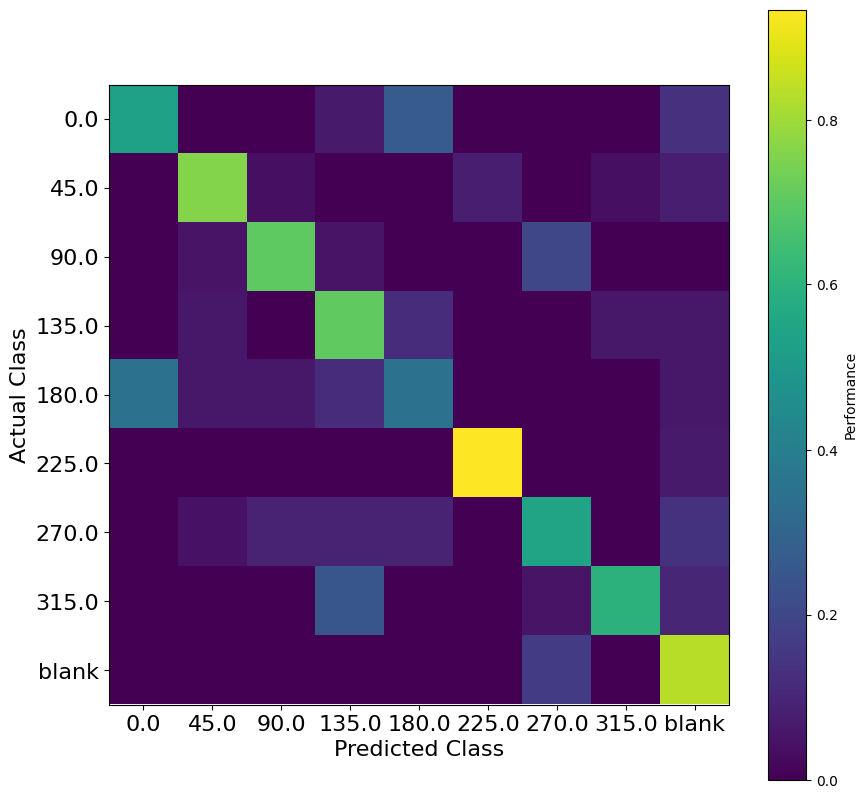

In [17]:
C = confusion_matrix(stim_test, stim_test_hat, normalize='true', labels=orientation_labels)
# Note that normalization is needed when all classes are not of the same size
# The default is to plot based on counts

num_classes = len(orientation_labels)

plt.figure(figsize=(10, 10))
ax = plt.subplot(111)
cax = ax.imshow(C,interpolation='none', vmin=0, vmax=C.max())

ax.set_xlabel('Predicted Class', fontsize=16)
ax.set_ylabel('Actual Class', fontsize=16)

ax.set_xticks(range(num_classes))
ax.set_xticklabels(orientation_labels, fontsize=16)

ax.set_yticks(range(num_classes))
ax.set_yticklabels(orientation_labels, fontsize=16)

cbar = plt.colorbar(cax)
cbar.set_label('Performance')

We see adding neurons provides more information to the classifier.  How many neurons do we need for good accuracy?

Let's examine how the decoding performance depends upon the number of neurons by randomly selecting a group of neurons of each size.  What does this tell us?  How can we improve this measurement?

In [18]:
performance = np.zeros(num_neurons-2)

test_index = int(0.75*num_trials)
stim_test_n = stim[test_index:]
stim_train_n = stim[:test_index]

for n in range(2, num_neurons):
  neuron_indices = np.random.permutation(np.arange(num_neurons))[:n] # choose n random neurons

  response_test_n = response[test_index:, neuron_indices]
  response_train_n = response[:test_index, neuron_indices]

  n_classifier = LDA()
  n_classifier.fit(response_train_n, stim_train_n)

  stim_test_hat_n = n_classifier.predict(response_test_n)

  performance[n-2] = np.mean(stim_test_hat_n == stim_test_n)

Text(0.5, 0, 'number of neurons')

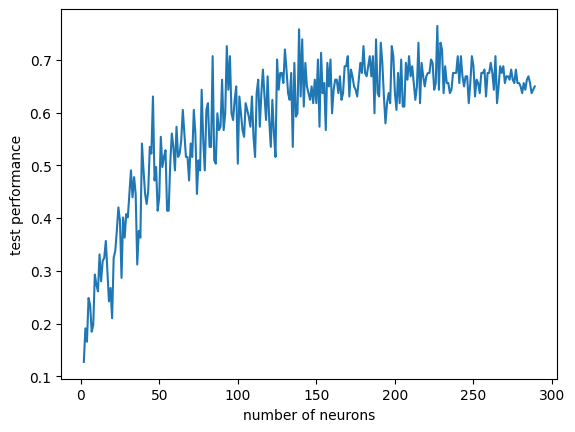

In [19]:
plt.plot(np.arange(2,num_neurons), performance)
plt.ylabel('test performance')
plt.xlabel('number of neurons')

Questions for future directions:

1. How did we define the test and train sets for these classifications?  What effects do you think this might have on our result?  Can you think of a better way?  What results do you get?

2. Which neurons are the most informative, i.e. which neurons carry the most weight for the classification?  What are the tuning properties of these neurons (i.e. how does the tuning curve relate to the weights in the classifier)?  If you used a different classifier, how would that change your answer to this question?

3.  How would you select the "best" neurons for decoding?  In machine learning this problem is called feature selection.  What methods might be best for this problem?  What are the results?  Are the neurons that are best for decoding the same as the neurons that have robust tuning curves?

4.  If you grab another experiment (code below), what do you need to keep in mind if you want to compare decoding performance across the two experiments?  what can you conclude (if anything) by comparing these two experiments?

In [20]:
def get_experiment_session_list():
    """Returns a list of session_ids for all sessions that use the drifting grating stimulus
    from areas VISp and VISl and from cre lines Cux2 and Slc17"""
    return [x['id'] for x in boc.get_ophys_experiments(stimuli=['drifting_gratings'], 
                                                       targeted_structures=['VISp', 'VISl'], 
                                                       cre_lines=['Cux2-CreERT2','Slc17a7-IRES2-Cre'] )]

Important functions that we used and defined above:

```
# this returns the data for a session identified by session_id
data_set = boc.get_ophys_experiment_data(session_id)

# this returns the timestamps and delta-F/F traces for the set of neurons imaged in that session
timestamps, dff = data_set.get_dff_traces()

# this returns the stimulus information 
stim_table = data_set.get_stimulus_table('drifting_gratings')

# compute_stim_and_response is defined IN THIS NOTEBOOK.
response, stim = compute_stim_and_response(dff, stim_table)
# response is [num_trials, num_neurons] and stim is [num_trials]
# response[t,i] gives the response of neuron i to trial t
# stim[t] tells you the stimulus condition of the drifting grating for trial t

# compute_dg_tuning_curve is defined IN THIS NOTEBOOK
tuning_curves = compute_dg_tuning_curve(response, stim, stim_table)
# tuning_curves is [num_neurons, num_orientations-1]

```


In [21]:
get_experiment_session_list()

[704298735,
 653123929,
 662033243,
 502793808,
 501940850,
 506030579,
 653551965,
 503109347,
 663485329,
 524691284,
 672207947,
 501574836,
 657080632,
 645413759,
 510514474,
 501704220,
 683257169,
 502205092,
 645256361,
 679702884,
 664404274,
 661328410,
 661437140,
 662348804,
 501271265,
 702934964,
 682051855,
 647595665,
 501836392,
 688678766,
 653122667,
 652842572,
 699155265,
 653125130,
 645700487,
 510517131,
 506823562,
 704822876,
 509958730,
 646016204,
 662358771,
 680156911,
 506809539,
 660513003,
 552410386,
 667364442,
 712178511,
 657082055,
 658536111,
 647155122,
 507990552,
 652737867,
 664914611,
 651770186,
 662974315,
 707923645,
 529688779,
 502115959,
 662219852,
 653932505,
 613091721,
 652094901,
 502608215]